In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from qiskit.circuit.library import ZZFeatureMap, PauliFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC

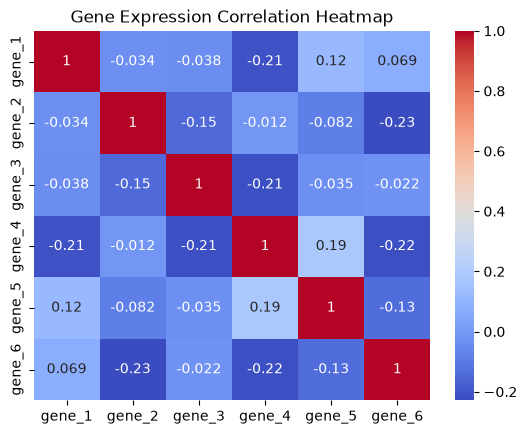

In [ ]:
np.random.seed(42)
n = 100
data = {
    'sample_id': range(1, n+1),
    'gene_1': np.random.rand(n),
    'gene_2': np.random.rand(n),
    'gene_3': np.random.rand(n),
    'gene_4': np.random.rand(n),
    'gene_5': np.random.rand(n),
    'gene_6': np.random.rand(n),
}
df = pd.DataFrame(data)
score = 2*df.gene_1 - 1.5*df.gene_3 + df.gene_5 + np.random.normal(0, 0.3, n)
df['tumor_type'] = (score > score.median()).astype(int)
df.to_csv('gene_expression.csv', index=False)

X = df[[f'gene_{i}' for i in range(1,7)]].values
y = df['tumor_type'].values

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_scaled)

sns.heatmap(df[[f'gene_{i}' for i in range(1,7)]].corr(), annot=True, cmap='coolwarm')
plt.title('Gene Expression Correlation Heatmap')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.25, stratify=y, random_state=42
)

In [7]:
def kernel_alignment(K, y):
    y_pm1 = np.where(y == 1, 1, -1)
    Y = np.outer(y_pm1, y_pm1)
    return np.sum(K * Y) / (np.linalg.norm(K) * np.linalg.norm(Y))

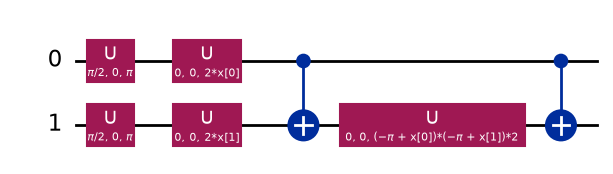

In [8]:
from qiskit.circuit.library import zz_feature_map

feature_dim = 2
zz_map = zz_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1
)
zz_map.decompose(reps=1).draw("mpl", scale=1)

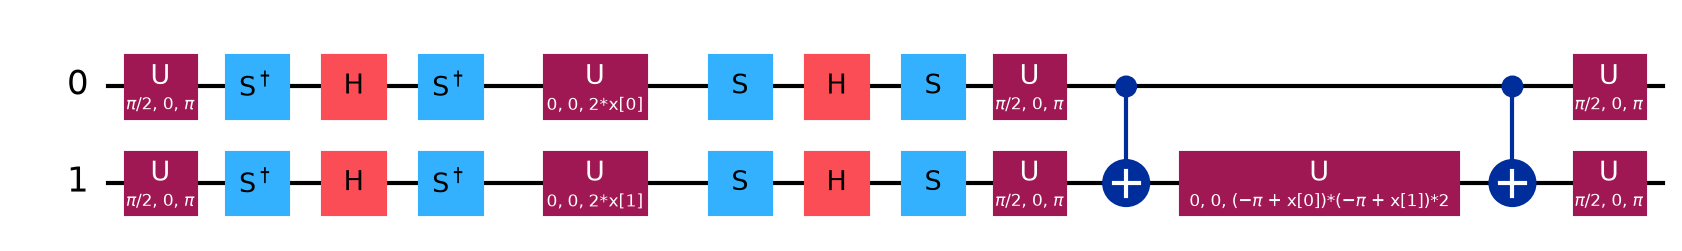

In [10]:
from qiskit.circuit.library import pauli_feature_map

feature_dim = 2
pauli_map = pauli_feature_map(
    feature_dimension=feature_dim, entanglement="linear", reps=1, paulis=["Y", "XX"]
)

pauli_map.decompose().draw("mpl", scale=1.5)

ZZFeatureMap kernel alignment: 0.0145


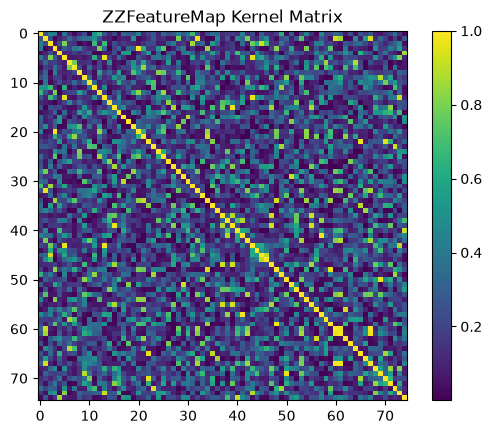

PauliFeatureMap kernel alignment: 0.0119


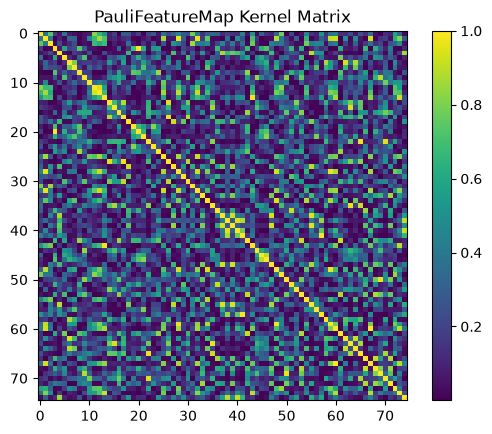

In [12]:
for name, fmap in [('ZZFeatureMap', zz_map), ('PauliFeatureMap', pauli_map)]:
    kernel = FidelityQuantumKernel(feature_map=fmap)
    K_train = kernel.evaluate(x_vec=X_train)
    align = kernel_alignment(K_train, y_train)
    print(f'{name} kernel alignment: {align:.4f}')
    plt.imshow(K_train, cmap='viridis')
    plt.title(f'{name} Kernel Matrix')
    plt.colorbar()
    plt.show()

best_map = zz_map
quantum_kernel = FidelityQuantumKernel(feature_map=best_map)

In [13]:
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train, y_train)
y_pred = qsvc.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.4
              precision    recall  f1-score   support

           0       0.43      0.46      0.44        13
           1       0.36      0.33      0.35        12

    accuracy                           0.40        25
   macro avg       0.40      0.40      0.40        25
weighted avg       0.40      0.40      0.40        25

[[6 7]
 [8 4]]


In [ ]:
h = 0.05
x_min, x_max = X_reduced[:,0].min()-0.5, X_reduced[:,0].max()+0.5
y_min, y_max = X_reduced[:,1].min()-0.5, X_reduced[:,1].max()+0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = qsvc.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train, edgecolors='k')
plt.title('QSVM Decision Boundary')
plt.show()